# 238. Product of Array Except Self
https://leetcode.com/problems/product-of-array-except-self/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Division | O(n) | O(1) | Total product / each element (not allowed) |
| Prefix + Suffix arrays | O(n) | O(n) | Two separate arrays for left/right products |
| **Prefix + Running suffix** | **O(n)** | **O(1)** | **Output array as prefix, then multiply suffix in-place** |

## Methodology

We solve this **without division** in O(n) time and O(1) extra space (output array not counted). First pass (left to right): build prefix products in the output array. Second pass (right to left): multiply each position by the running suffix product. Each element ends up as the product of all elements except itself.

## Solutions

### C#

In [ ]:
// 238. Product of Array Except Self
// Time: O(n) | Space: O(1) extra
public class Solution {
    public int[] ProductExceptSelf(int[] nums) {
        int n = nums.Length;
        int[] result = new int[n];
        
        // Left pass: prefix products
        result[0] = 1;
        for (int i = 1; i < n; i++)
            result[i] = result[i - 1] * nums[i - 1];
        
        // Right pass: multiply by suffix products
        int suffix = 1;
        for (int i = n - 1; i >= 0; i--) {
            result[i] *= suffix;
            suffix *= nums[i];
        }
        
        return result;
    }
}

### Python

In [ ]:
# 238. Product of Array Except Self
# Time: O(n) | Space: O(1) extra
class Solution:
    def productExceptSelf(self, nums: list[int]) -> list[int]:
        n = len(nums)
        result = [1] * n
        
        # Left pass: prefix products
        for i in range(1, n):
            result[i] = result[i - 1] * nums[i - 1]
        
        # Right pass: multiply by suffix products
        suffix = 1
        for i in range(n - 1, -1, -1):
            result[i] *= suffix
            suffix *= nums[i]
        
        return result

### Go

In [ ]:
// 238. Product of Array Except Self
// Time: O(n) | Space: O(1) extra
func productExceptSelf(nums []int) []int {
    n := len(nums)
    result := make([]int, n)
    
    // Left pass: prefix products
    result[0] = 1
    for i := 1; i < n; i++ {
        result[i] = result[i-1] * nums[i-1]
    }
    
    // Right pass: multiply by suffix products
    suffix := 1
    for i := n - 1; i >= 0; i-- {
        result[i] *= suffix
        suffix *= nums[i]
    }
    
    return result
}

### Rust

In [ ]:
// 238. Product of Array Except Self
// Time: O(n) | Space: O(1) extra
impl Solution {
    pub fn product_except_self(nums: Vec<i32>) -> Vec<i32> {
        let n = nums.len();
        let mut result = vec![1; n];
        
        // Left pass: prefix products
        for i in 1..n {
            result[i] = result[i - 1] * nums[i - 1];
        }
        
        // Right pass: multiply by suffix products
        let mut suffix = 1;
        for i in (0..n).rev() {
            result[i] *= suffix;
            suffix *= nums[i];
        }
        
        result
    }
}

## Example Scenarios

### 1. Common Case — Standard Array
**Input:** `nums = [1, 2, 3, 4]`

Prefix products: `[1, 1, 2, 6]`. Then suffix pass multiplies from right: `[24, 12, 8, 6]`. Each element equals the product of all others without using division.

### 2. Slightly Complex — Array Contains a Zero
**Input:** `nums = [1, 2, 0, 4]`

The zero at index 2 makes every product zero except index 2 itself. Prefix: `[1, 1, 2, 0]`. Suffix pass: `[0, 0, 8, 0]`. Only position 2 gets a nonzero result ($1 \times 2 \times 4 = 8$).

### 3. Edge Case: Time Factor — Large Array
**Input:** `nums` has $n = 10^5$ elements, all equal to `2`

Two linear passes: prefix then suffix. Total work is $2n = 2 \times 10^5$ multiplications. Each output element equals $2^{n-1} = 2^{99999}$, but integer overflow is not an issue in Python. In languages with fixed-width integers, the problem guarantees products fit in 32 bits.

### 4. Edge Case: Space Factor — Two Elements (Minimum)
**Input:** `nums = [3, 5]`

Output: `[5, 3]` — each element is simply the other. The prefix/suffix arrays degenerate to trivial single-element products. Using $O(1)$ extra space (output array excluded), this is the minimal space scenario.

### 5. Almost-Impossible but Plausible — Two Zeros
**Input:** `nums = [0, 4, 0]`

With two zeros, every position's product includes at least one zero factor. Output: `[0, 0, 0]`. Even index 1 (between the zeros) gets $0 \times 0 = 0$. The algorithm handles this naturally — no special-case logic needed.

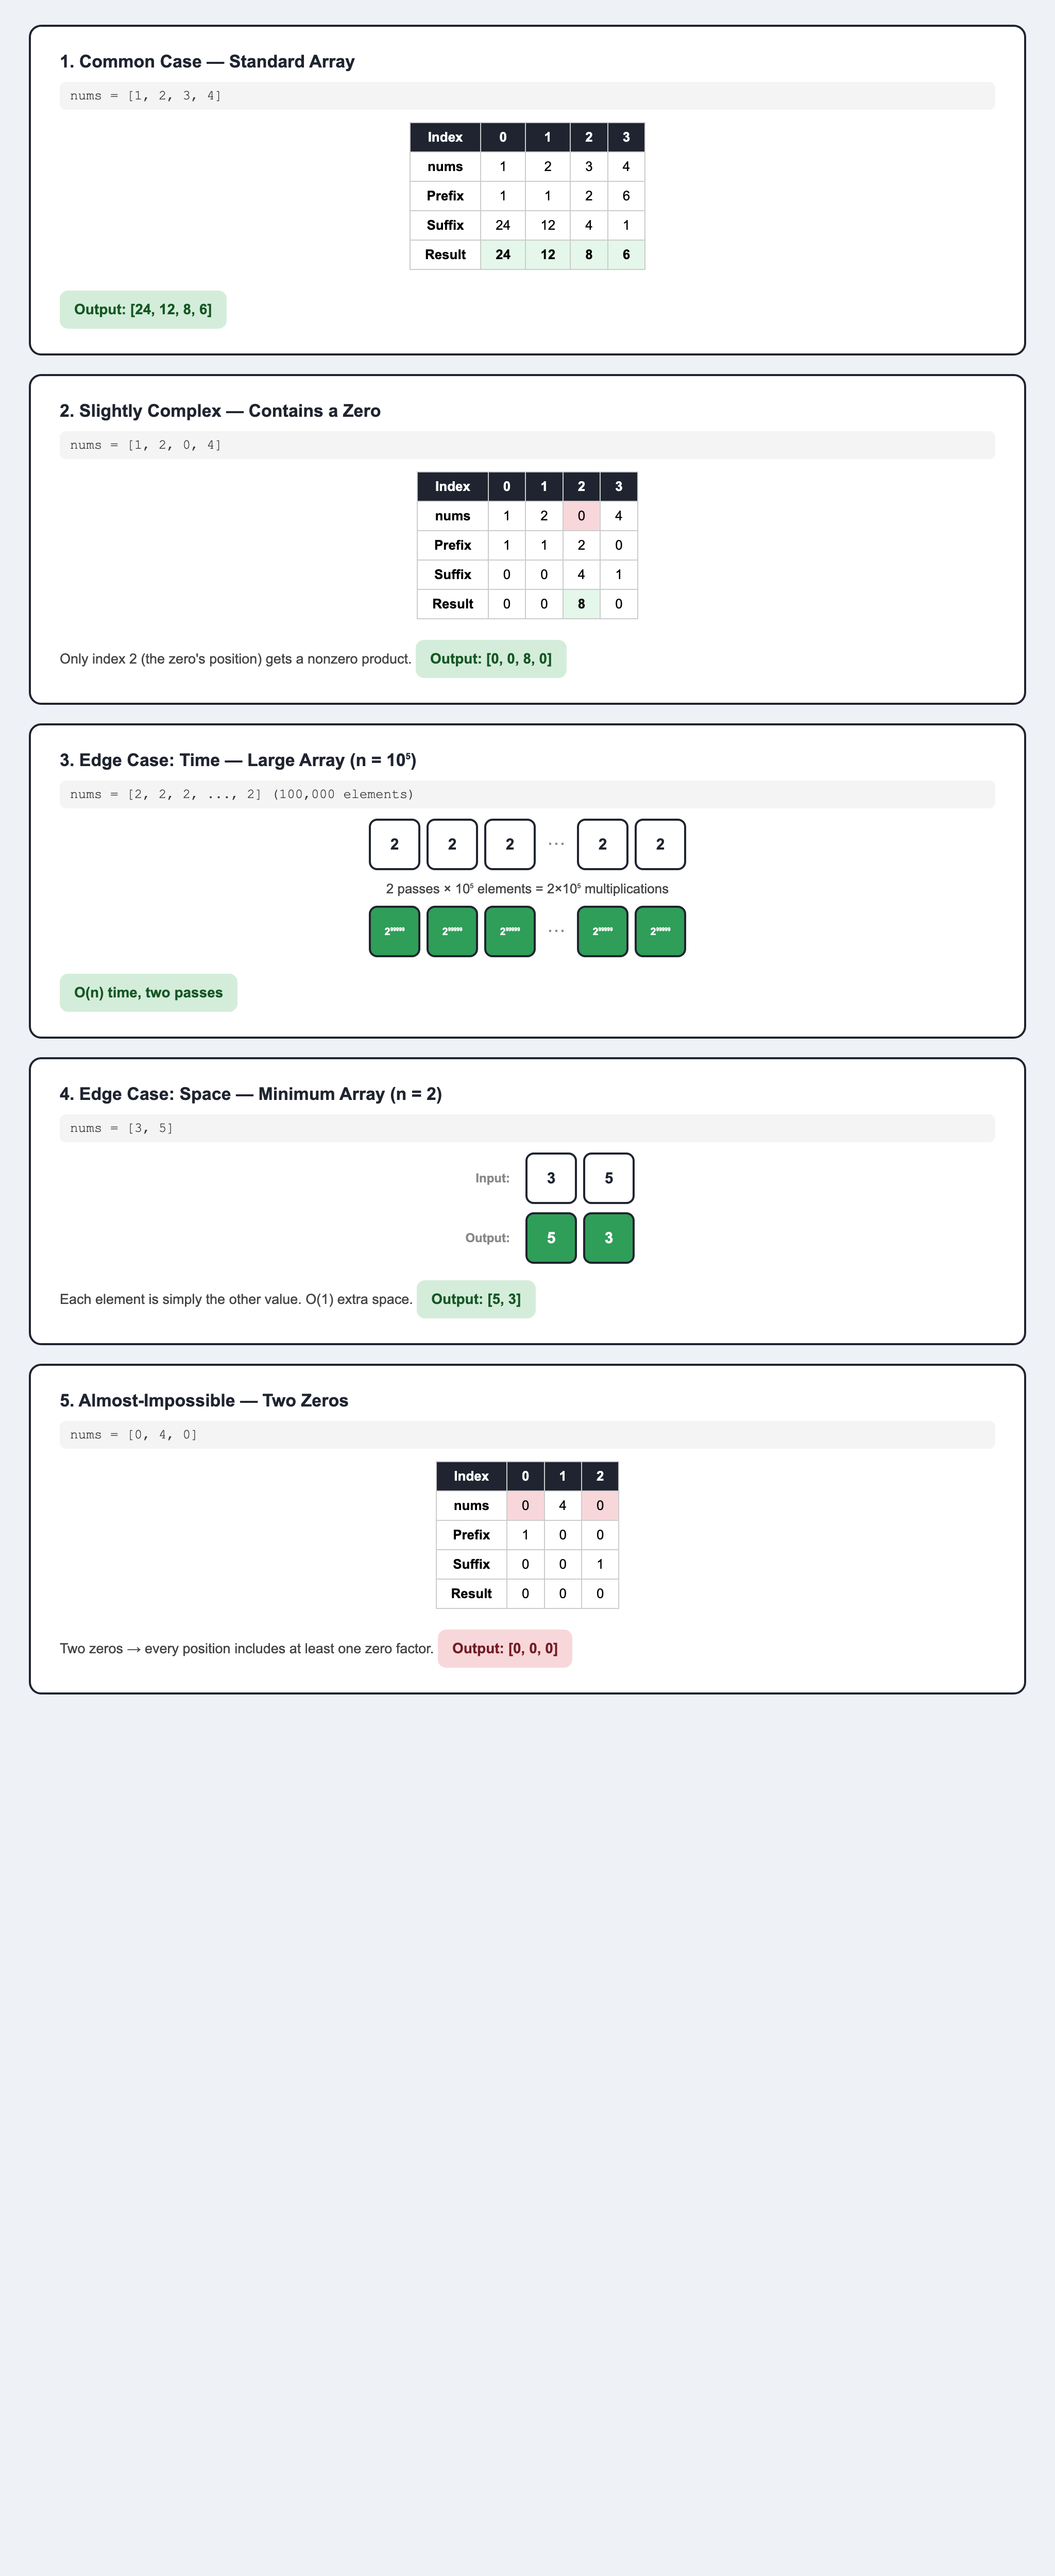